In [52]:
#importing all important libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_profiling as pp

from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report,silhouette_samples,silhouette_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import time
import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV,LogisticRegression
from sklearn.metrics import classification_report,roc_curve,auc
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from collections import Counter
import pandas_profiling as pp
# data preprocessing
from sklearn.preprocessing import StandardScaler

In [53]:
# import Google Drive 套件
from google.colab import drive
# 將自己的雲端硬碟掛載上去
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


##讀資料和分析資料

In [54]:
data =pd.read_csv('gdrive/My Drive/Colab Notebooks/資料科學/期末報告/ecommerce_data.csv',encoding="ISO-8859-1")


In [55]:
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [56]:
#探索資料
data.info

<bound method DataFrame.info of        InvoiceNo StockCode  ... CustomerID         Country
0         536365    85123A  ...    17850.0  United Kingdom
1         536365     71053  ...    17850.0  United Kingdom
2         536365    84406B  ...    17850.0  United Kingdom
3         536365    84029G  ...    17850.0  United Kingdom
4         536365    84029E  ...    17850.0  United Kingdom
...          ...       ...  ...        ...             ...
541904    581587     22613  ...    12680.0          France
541905    581587     22899  ...    12680.0          France
541906    581587     23254  ...    12680.0          France
541907    581587     23255  ...    12680.0          France
541908    581587     22138  ...    12680.0          France

[541909 rows x 8 columns]>

In [57]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


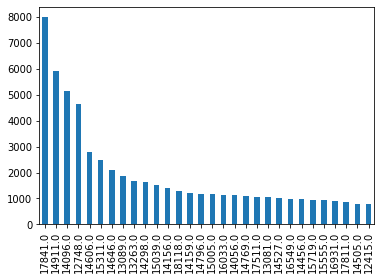

In [58]:
#清理前的數據中銷售額排名前30名的客戶。
data['CustomerID'].value_counts().head(30).plot(kind='bar')

##資料清理

In [59]:
#查看資料形狀
print(data.shape)

(541909, 8)


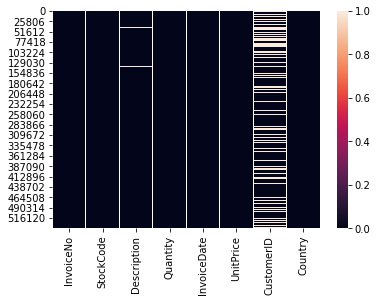

In [60]:
# 查看空值
sns.heatmap(data.isnull())

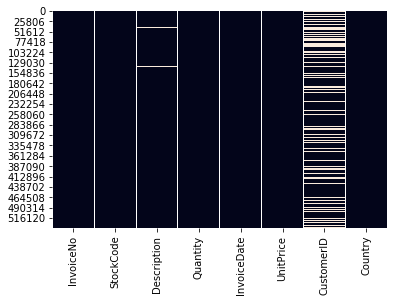

In [61]:
sns.heatmap(data.isnull(),cbar=False)

In [62]:
# 查看空值
data.isnull().any()

InvoiceNo      False
StockCode      False
Description     True
Quantity       False
InvoiceDate    False
UnitPrice      False
CustomerID      True
Country        False
dtype: bool

In [63]:
# 查看空值
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [64]:
data['CustomerID']=data['CustomerID'].fillna('Unknown')

In [65]:
data['Description']=data['Description'].fillna('Unknown')

In [66]:
 #移除空值
data.dropna(axis = 0, inplace = True)
print(data.shape)  

(541909, 8)


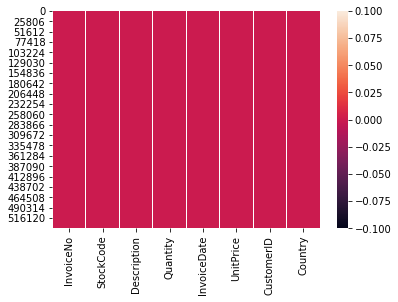

In [67]:
sns.heatmap(data.isnull())

我們可以觀察在刪除空值之前和刪除空值之後差異

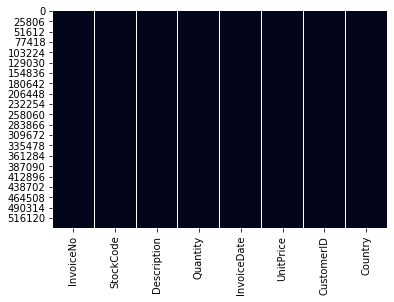

In [68]:
# 現在資料已經乾淨可以開始分析
sns.heatmap(data.isnull(),cbar=False)

In [69]:
data.isnull().any()

InvoiceNo      False
StockCode      False
Description    False
Quantity       False
InvoiceDate    False
UnitPrice      False
CustomerID     False
Country        False
dtype: bool

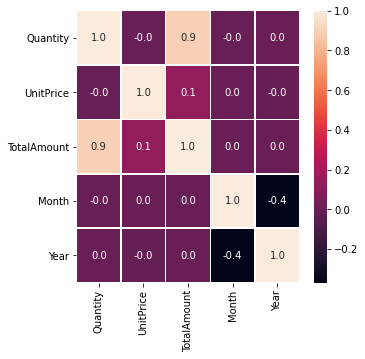

In [103]:
#訓練數據集的熱圖
#heatmap for train dataset
import seaborn as sns
import matplotlib.pyplot as plt
f,ax = plt.subplots(figsize=(5,5))
sns.heatmap(data.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

In [71]:
data = data[data['Quantity']>=0]
data = data[data['UnitPrice']>=0]

print(data.shape)

(531283, 8)


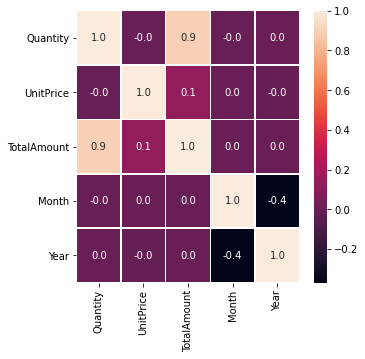

In [104]:
#訓練數據集的熱圖
#heatmap for train dataset
import seaborn as sns
import matplotlib.pyplot as plt
f,ax = plt.subplots(figsize=(5,5))
sns.heatmap(data.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

TypeError: ignored

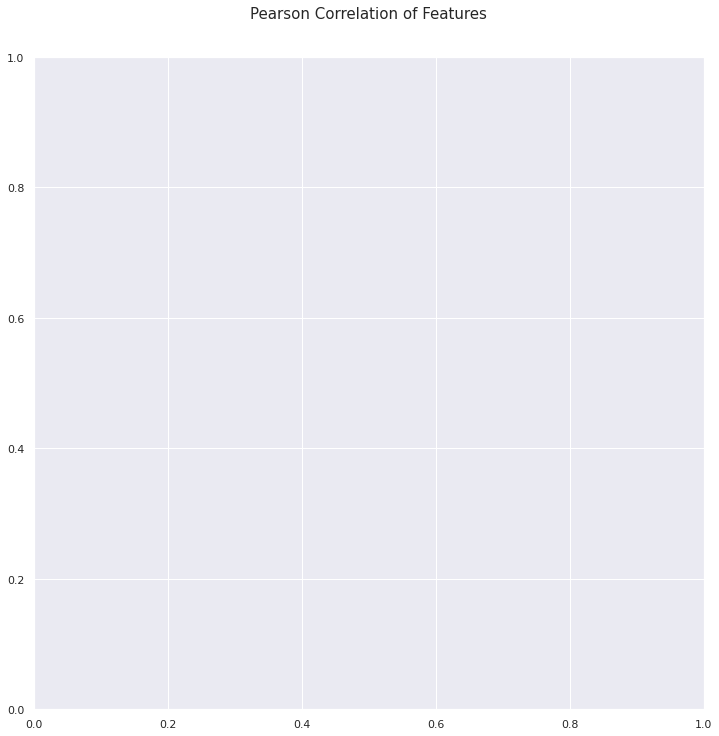

In [122]:
colormap = plt.cm.viridis
plt.figure(figsize=(12,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(data.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)

In [73]:
data.describe()

,Quantity,UnitPrice
count,531283.000000,531283.000000
mean,10.655299,3.898954
std,156.830617,35.876279
min,1.000000,0.000000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,13541.330000


In [74]:
data['TotalAmount'] = data['Quantity']*data['UnitPrice']
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34


我們要查看訂單和國家的信息

In [75]:
print(data[['InvoiceNo','Country']].groupby('Country').count().sort_values("InvoiceNo",ascending = False))

                      InvoiceNo
Country                        
United Kingdom           486284
Germany                    9042
France                     8408
EIRE                       7894
Spain                      2485
Netherlands                2363
Belgium                    2031
Switzerland                1967
Portugal                   1501
Australia                  1185
Norway                     1072
Italy                       758
Channel Islands             748
Finland                     685
Cyprus                      614
Sweden                      451
Unspecified                 446
Austria                     398
Denmark                     380
Poland                      330
Japan                       321
Israel                      295
Hong Kong                   284
Singapore                   222
Iceland                     182
USA                         179
Canada                      151
Greece                      145
Malta                       112
United A

In [106]:
print(data[['InvoiceNo','Description']].groupby('Description').count().sort_values("InvoiceNo",ascending = False))

                                    InvoiceNo
Description                                  
WHITE HANGING HEART T-LIGHT HOLDER       2327
JUMBO BAG RED RETROSPOT                  2115
REGENCY CAKESTAND 3 TIER                 2019
PARTY BUNTING                            1707
LUNCH BAG RED RETROSPOT                  1594
...                                       ...
BLUE CRYSTAL BOOT PHONE CHARM               1
FLOWER SHOP DESIGN MUG                      1
BLUE DROP EARRINGS W BEAD CLUSTER           1
LUNCH BAG RED SPOTTY                        1
wrongly sold (22719) barcode                1

[4074 rows x 1 columns]


In [107]:
print(data[['InvoiceNo','Quantity']].groupby('Quantity').count().sort_values("InvoiceNo",ascending = False))

          InvoiceNo
Quantity           
1            148225
2             81829
12            61063
6             40868
4             38484
...             ...
588               1
608               1
122               1
253               1
80995             1

[393 rows x 1 columns]


In [111]:
print(data[['InvoiceNo','UnitPrice']].groupby('UnitPrice').count().sort_values("InvoiceNo",ascending = False))

           InvoiceNo
UnitPrice           
1.25           49753
1.65           37498
0.85           28061
2.95           27106
0.42           24302
...              ...
135.13             1
135.67             1
135.75             1
136.38             1
13541.33           1

[1292 rows x 1 columns]


In [112]:
print(data[['InvoiceNo','CustomerID']].groupby('CustomerID').count().sort_values("InvoiceNo",ascending = False))

            InvoiceNo
CustomerID           
Unknown        133359
17841.0          7847
14911.0          5677
14096.0          5111
12748.0          4596
...               ...
17925.0             1
15823.0             1
15802.0             1
13302.0             1
12346.0             1

[4340 rows x 1 columns]


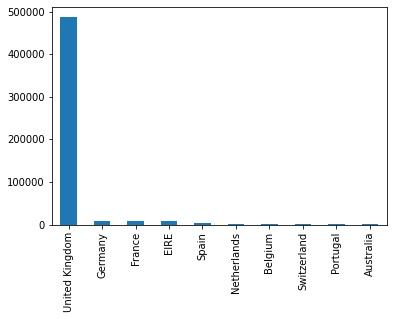

In [76]:
#清理後的數據中銷售額排名前10名的國家。
data['Country'].value_counts().head(10).plot(kind='bar')

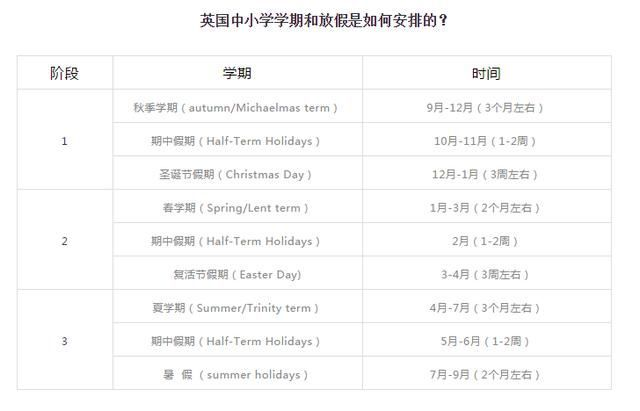

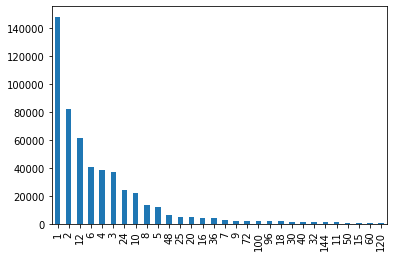

In [77]:
#清理後的數據中銷售數量排名前30名。
data['Quantity'].value_counts().head(30).plot(kind='bar')

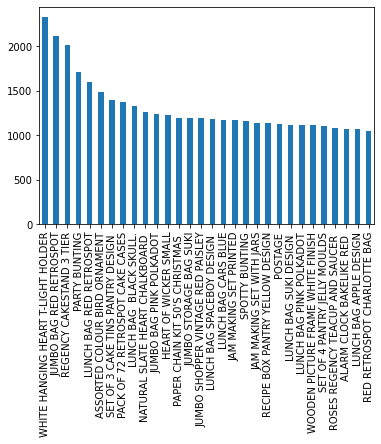

In [78]:
#清理後的數據中熱銷排行排名前30名。
data['Description'].value_counts().head(30).plot(kind='bar')

In [79]:
data[data['TotalAmount']==data['TotalAmount'].max()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446,United Kingdom,168469.6


In [80]:
items = data['Description'].value_counts().head()
print(items)

WHITE HANGING HEART T-LIGHT HOLDER    2327
JUMBO BAG RED RETROSPOT               2115
REGENCY CAKESTAND 3 TIER              2019
PARTY BUNTING                         1707
LUNCH BAG RED RETROSPOT               1594
Name: Description, dtype: int64


In [81]:
print(data[['InvoiceNo','Country','CustomerID','TotalAmount']].sort_values('TotalAmount',ascending = False).head(15))

       InvoiceNo         Country CustomerID  TotalAmount
540421    581483  United Kingdom      16446    168469.60
61619     541431  United Kingdom      12346     77183.60
222680    556444  United Kingdom      15098     38970.00
15017     537632  United Kingdom    Unknown     13541.33
299982   A563185  United Kingdom    Unknown     11062.06
173382    551697  United Kingdom      16029      8142.75
348325    567423  United Kingdom      17450      7144.72
52711     540815  United Kingdom      15749      6539.40
160546    550461  United Kingdom      15749      6539.40
421601    573003     Netherlands      14646      4992.00
52709     540815  United Kingdom      15749      4921.50
467804    576365  United Kingdom    Unknown      4781.60
160542    550461  United Kingdom      15749      4632.00
52772     540818  United Kingdom      15749      4522.50
297723    562955  United Kingdom    Unknown      4505.17


In [82]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['Date'] = data['InvoiceDate'].apply(lambda x: x.date())
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01


In [83]:
data['Month']=data['InvoiceDate'].apply(lambda x:x.month)
data['Year']=data['InvoiceDate'].apply(lambda x:x.year)
data=data.sort_values(by=['Year','Month'])

mmap={1:'Jan11',2:'Feb11',3:'Mar11',4:'Apr11', 5:'May11', 6:'Jun11', 7:'Jul11',8:'Aug11',9:'Sep11',10:'Oct11',11:'Nov11',12:'Dec11'}
data['Month_name']=data['Month'].map(mmap)

In [84]:
def my(x):
    Month=x[0]
    Year=x[1]
    
    if Year==2010:
        Month='Dec10'
        return Month
    else:
        return Month

In [85]:
data['Month_name']=data[['Month_name','Year']].apply(my, axis=1)

In [86]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Date,Month,Year,Month_name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01,12,2010,Dec10
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,12,2010,Dec10
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01,12,2010,Dec10
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,12,2010,Dec10
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,12,2010,Dec10


In [87]:
monthly=data.groupby(['Year','Month','Month_name']).sum()
monthly.head()

Quantity   UnitPrice  TotalAmount
Year Month Month_name                                   
2010 12    Dec10         362316  199904.470   823746.140
2011 1     Jan11         397716  129735.010   691364.560
     2     Feb11         286695  108169.960   523631.890
     3     Mar11         384950  145628.240   717639.360
     4     Apr11         312176  115603.731   537808.621

In [108]:
print(data[['InvoiceNo','Month']].groupby('Month').count().sort_values("InvoiceNo",ascending = False))

       InvoiceNo
Month           
11         83498
12         66818
10         59396
9          49323
7          38716
5          36292
6          36056
3          35915
8          34564
1          34350
4          29171
2          27184


In [109]:
print(data[['InvoiceNo','Date']].groupby('Date').count().sort_values("InvoiceNo",ascending = False))

            InvoiceNo
Date                 
2011-12-05       5302
2011-12-08       4871
2011-11-29       4295
2011-11-16       4150
2011-11-11       4071
...               ...
2011-08-07        529
2010-12-19        518
2011-05-01        448
2010-12-22        286
2011-02-06        279

[305 rows x 1 columns]


In [110]:
print(data[['InvoiceNo','Month_name']].groupby('Month_name').count().sort_values("InvoiceNo",ascending = False))

            InvoiceNo
Month_name           
Nov11           83498
Oct11           59396
Sep11           49323
Dec10           41683
Jul11           38716
May11           36292
Jun11           36056
Mar11           35915
Aug11           34564
Jan11           34350
Apr11           29171
Feb11           27184
Dec11           25135


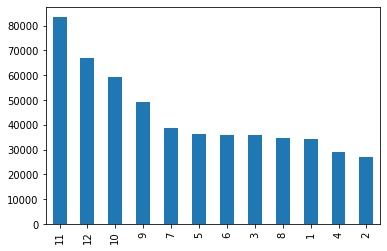

In [88]:
#清理後的數據中月份的總銷售額。
data['Month'].value_counts().head(12).plot(kind='bar')

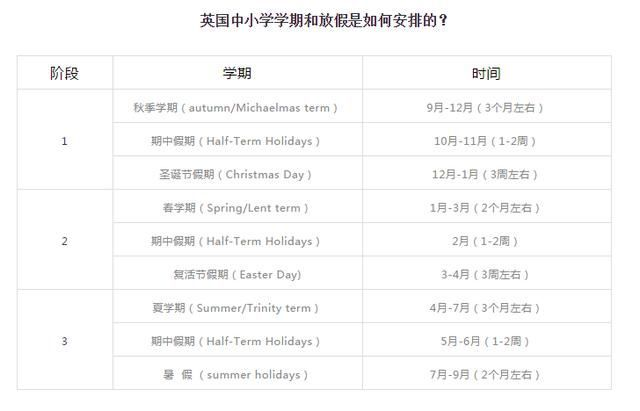

In [89]:
#recency dataframe
recency_df = data.groupby(by='CustomerID', as_index=False)['Date'].max()
recency_df.columns = ['CustomerID','LastPurchaseDate']
recency_df.head(5)

,CustomerID,LastPurchaseDate
0,12346,2011-01-18
1,12347,2011-12-07
2,12348,2011-09-25
3,12349,2011-11-21
4,12350,2011-02-02


In [90]:
current = dt.date(2021,12,1)
print(current)


2021-12-01


#創造RFM表格

In [91]:
recency_df['Recency'] = recency_df['LastPurchaseDate'].apply(lambda x: (current - x).days)
recency_df.drop('LastPurchaseDate',axis = 1,inplace=True)
recency_df.head(5)

,CustomerID,Recency
0,12346,3970
1,12347,3647
2,12348,3720
3,12349,3663
4,12350,3955


In [92]:
temp = data.copy()
temp.drop_duplicates(['InvoiceNo','CustomerID'],keep='first',inplace=True)
frequency_df = temp.groupby(by=['CustomerID'], as_index=False)['InvoiceNo'].count()
frequency_df.columns = ['CustomerID','Frequency']
frequency_df.head()

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [93]:
monetary_df = data.groupby(by = 'CustomerID',as_index=False).agg({'TotalAmount':'sum'})
monetary_df.columns = ['CustomerID','TotalAmount']
monetary_df.head(5)

,CustomerID,TotalAmount
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


RFM 分析
RFM(Recency, Frequency, Monetary)分析是一種客戶細分技術，它使用過去的購買行為將客戶分組。 
RFM 幫助將客戶劃分為各種類別或集群，以識別更有可能響應促銷和未來個性化服務的客戶。






1.   RECENCY (R)：消費周期-從上次購買以來的天數
2.   FREQUENCY (F)：消費頻率-購買幾次
3.MONETARY VALUE (M)：消費金額-該客戶花費的總金





額。                                       我們將為每個客戶創建這 3 個客戶屬性。


> 可以找出常客新客貴客



In [94]:
rfm_df = recency_df.merge(frequency_df,on='CustomerID').merge(monetary_df,on='CustomerID')
rfm_df.set_index('CustomerID',inplace=True)
rfm_df.head()

,Recency,Frequency,TotalAmount
CustomerID,,,
12346.0,3970,1,77183.60
12347.0,3647,7,4310.00
12348.0,3720,4,1797.24
12349.0,3663,1,1757.55
12350.0,3955,1,334.40


In [95]:
features = rfm_df.columns
rfm_df.shape

(4340, 3)

RFM 表格可視化
現在我們要看RFM表格的Recency、Frequenc和Monetary之間的相關性，這將是客戶細分的一個組成部分

              Recency  Frequency  TotalAmount
Recency      1.000000  -0.072519    -0.052327
Frequency   -0.072519   1.000000     0.962979
TotalAmount -0.052327   0.962979     1.000000


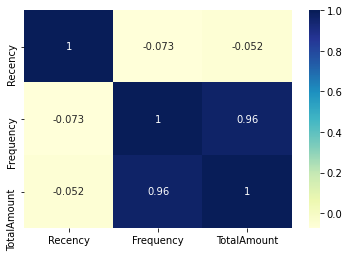

In [96]:
print(rfm_df.corr())
sns.heatmap(rfm_df.corr(),cmap="YlGnBu",annot=True)

In [97]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
rfm_df = pd.DataFrame(pt.fit_transform(rfm_df))
rfm_df.columns = features
rfm_df.head()

/usr/local/lib/python3.7/dist-packages/sklearn/preprocessing/_data.py:2982: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())


,Recency,Frequency,TotalAmount
0,0.0,-1.157941,3.153369
1,0.0,1.200958,1.370436
2,0.0,0.660000,0.743707
3,0.0,-1.157941,0.727129
4,0.0,-1.157941,-0.590061


#PCA主成份分析

利用Principle Component Analysis (PCA)對電子商務數據進行維度縮減
結論
為了進一步了解客戶行為，我們可以深入挖掘 RFM 變量之間的關係。

RFM 模型可以與某些預測模型（如 K-means 聚類、邏輯回歸和推薦引擎）結合使用，以產生更好的客戶行為信息結果。

我們將選擇 K-means，因為它已被廣泛用於市場細分，並且具有易於實施的優勢。
我們將有相關的變數減少成少數幾個沒有相關的主成份

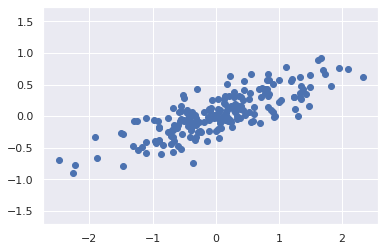

In [113]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

#生成數據
rng = np.random.RandomState(1) #seed()
X = np.dot(rng.rand(8,3), rng.randn(3, 200)).T   #shape(200,8)
plt.scatter(X[:, 0], X[:, 1])  
plt.axis('equal');

pca.explained_variance_ratio_ [0.8165667764719907, 0.1417944402250787, 0.04163878330293063, 9.931059050726861e-33, 3.625060534189947e-33, 1.3886091671879278e-33, 9.664238894569148e-34, 4.900125871375616e-34]


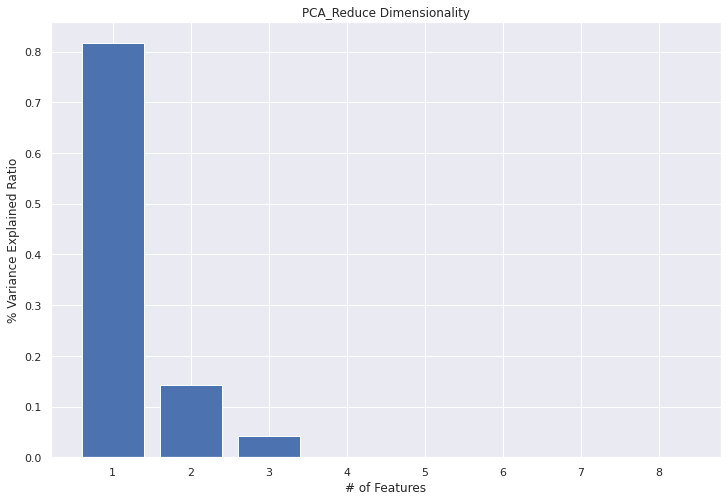

In [114]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=8)
pca.fit(X)

#選定主成分數
explained = pca.explained_variance_ratio_  #看新特徵的解釋能力: 選擇
plt.figure(figsize=(12,8))
plt.title('PCA_Reduce Dimensionality')
features = range(1,pca.n_components_+1)
plt.ylabel('% Variance Explained Ratio')
plt.xlabel('# of Features')
plt.bar(features,explained)
print('pca.explained_variance_ratio_',pca.explained_variance_ratio_.tolist())

In [115]:
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape:   ", X.shape)
print("transformed shape:", X_pca.shape)

print(np.cumsum(pca.explained_variance_ratio_))  #把解釋能力累加起來，看看我們總共保留了多少特徵貢獻度。

X_new = pca.inverse_transform(X_pca) #很像原x,去噪

original shape:    (200, 8)
transformed shape: (200, 2)
[0.81656678 0.95836122]


In [116]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [117]:
pca.explained_variance_ratio_

array([0.81656678, 0.14179444])

In [119]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='rainbow',
    alpha=0.7,
    edgecolors='b'
)

NameError: ignored

應用 PCA 來減少頻率和貨幣特徵之間的維度和相關性

#模型訓練

#K-Means Clustering(k最近鄰居分類法)

推論：
我們從肘部圖中觀察到聚集增加2個以後出現急劇彎曲。 Silhoutte 分數也是 2 個聚集的最高值。

但是，隨著集群數量從2增加到4，並且在4之後，減少的並不多，因此集群錯誤也顯著減少。

因此，我們將選擇 n_clusters=4來正確細分我們的客戶。

#DecisionTreeClassifier

In [98]:
from sklearn.tree import DecisionTreeClassifier

#KNN

#Gaussian Naive Bayes Classifier

結論
我們看到，使用 Logisitc Regression、KNeighborsClassifier、DecisionTree 等分類模型，我們使用 RFM 數據集作為自變量和集群作為目標變量為客戶預測了集群。 分類模型預測的聚類與 K-Means 聚類完全一致。 因此，我們可以得出結論，我們的集群是正確的。

總結
這個數據庫提供了一年內在電子商務平台上進行的購買的詳細信息。數據集中的每個項目都描述了特定客戶在特定日期購買的產品。總共有大約 4000 個客戶出現在數據庫中。因此，我決定把客戶分類，希望可以預測客戶的購物行為。
分析的下一部分包括一些基本的數據可視化。這樣做是為了深入了解使用電子商務網站最多的國家/地區。我使用基本圖來顯示我的分析結果。我還嘗試分析了其他重要因素，例如一個國家的總購買量以及以下哪個描述使用最多。

分析的最後一部分是客戶細分部分。處理此過程的主要方法是使用 RFM（消費日期、消費平率、消費金額）表對組中的客戶進行排序。創建 RFM 表後，我使用 K-Means 聚類（肘部曲線和 Silhoutte 分數）來創建 4 個聚類，其中應該對客戶進行細分。在將每個客戶細分為各自的組之後。我使用了諸如 Logisitc Regression、KNeighborsClassifier、DecisionTree 之類的模型來交叉聚類的準確性，從而得到 0.98 的準確性分數。因此，我得出結論，客戶細分是有效的方法和高精度。

In [99]:
data[data['CustomerID'] == 17841]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Date,Month,Year,Month_name
2037,536557,21495,SKULLS AND CROSSBONES WRAP,25,2010-12-01 14:41:00,0.42,17841,United Kingdom,10.50,2010-12-01,12,2010,Dec10
2038,536557,46000R,POLYESTER FILLER PAD 45x30cm,2,2010-12-01 14:41:00,1.45,17841,United Kingdom,2.90,2010-12-01,12,2010,Dec10
2039,536557,46000S,POLYESTER FILLER PAD 40x40cm,1,2010-12-01 14:41:00,1.45,17841,United Kingdom,1.45,2010-12-01,12,2010,Dec10
2040,536557,22731,3D CHRISTMAS STAMPS STICKERS,1,2010-12-01 14:41:00,1.25,17841,United Kingdom,1.25,2010-12-01,12,2010,Dec10
2041,536557,21258,VICTORIAN SEWING BOX LARGE,1,2010-12-01 14:41:00,12.75,17841,United Kingdom,12.75,2010-12-01,12,2010,Dec10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
537749,581334,23399,HOME SWEET HOME HANGING HEART,3,2011-12-08 12:07:00,0.85,17841,United Kingdom,2.55,2011-12-08,12,2011,Dec11
537750,581334,22893,MINI CAKE STAND T-LIGHT HOLDER,12,2011-12-08 12:07:00,0.42,17841,United Kingdom,5.04,2011-12-08,12,2011,Dec11
537751,581334,22371,AIRLINE BAG VINTAGE TOKYO 78,1,2011-12-08 12:07:00,4.25,17841,United Kingdom,4.25,2011-12-08,12,2011,Dec11
537752,581334,22309,TEA COSY RED STRIPE,1,2011-12-08 12:07:00,2.55,17841,United Kingdom,2.55,2011-12-08,12,2011,Dec11


In [100]:
# 按用戶 ID 分組：
purchase = data.groupby(['CustomerID']).sum().reset_index()

In [101]:
purchase.head

<bound method NDFrame.head of      CustomerID  Quantity  UnitPrice   TotalAmount   Month       Year
0         12346     74215       1.04  7.718360e+04       1       2011
1         12347      2458     481.21  4.310000e+03    1383     365971
2         12348      2341     178.71  1.797240e+03     257      62324
3         12349       631     605.10  1.757550e+03     803     146803
4         12350       197      65.30  3.344000e+02      34      34187
...         ...       ...        ...           ...     ...        ...
4335      18281        54      39.36  8.082000e+01      42      14077
4336      18282       103      62.39  1.780500e+02     116      24132
4337      18283      1397    1220.93  2.094880e+03    5503    1520316
4338      18287      1586     104.55  1.837280e+03     555     140770
4339    Unknown    479283  831447.16  1.755277e+06  987417  268169426

[4340 rows x 6 columns]>

In [102]:
type(purchase)

pandas.core.frame.DataFrame